In [49]:
import torch
from torchvision import datasets,transforms, models
from torch.utils.data import DataLoader
from torch import optim

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [59]:
#Load the data and Augmentation
#DATA_DIR = "D:/MSCS_Research/Datasets/RAW/fitzpatrick17k/main_data"
#DATA_DIR = "D:/MSCS_Research/Datasets/RAW/PASSION_MICCAI_2024/passion2024"
#DATA_DIR = "D:/MSCS_Research/Datasets/RAW/sd-198/SD_198"
DATA_DIR = "D:/MSCS_Research/Datasets/Inputs/8Way_5SHot"
test_data = f"{DATA_DIR}"
validation_data = f"{DATA_DIR}"

batch_size = 10

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(test_data, transform=train_transform)
validation_dataset = datasets.ImageFolder(test_data, transform=val_transform)

train_dataloader = DataLoader( train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader( validation_dataset, batch_size =batch_size, shuffle=True)

num_classes = len(train_dataset.classes)
image_folders = train_dataset.imgs
print(num_classes)


8


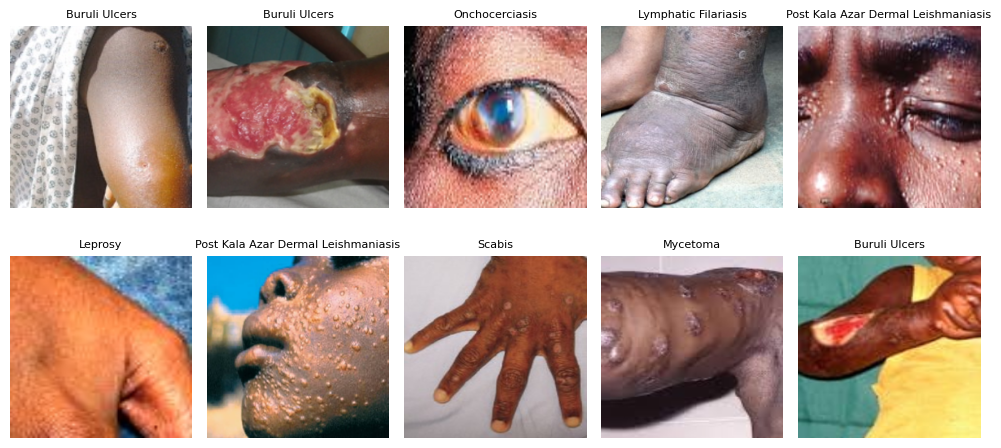

In [65]:
#View the Sample of the loaded Dataset
import matplotlib.pyplot as plt
import numpy as np


images, labels = next(iter(train_dataloader))
mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)

images = images * std+mean
images = images.clamp(0,1)

fig, axes = plt.subplots(2, 5, figsize=(10,5))
axes = axes.flatten()

for i in range(10):

    img =  images[i].permute(1,2,0).numpy()
    label_name = train_dataset.classes[labels[i]]

    axes[i].imshow(img)
    axes[i].set_title(label_name, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()



In [14]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [15]:
#Load the model
from torchinfo import summary
from torch import nn

pretrained_model = models.densenet161(weights=models.DenseNet161_Weights.IMAGENET1K_V1)

# Replacing the Classifer head with a new one matching our data
pretrained_model.classifier = nn.Linear(pretrained_model.classifier.in_features, num_classes)

#freezing the backbone for feature extractor
for param in pretrained_model.features.parameters():
    param.requires_grad=False

#How many learnable parameters after  freezing the backbone
sum(param.numel() for param in pretrained_model.parameters() if param.requires_grad)


249617

In [16]:
#The summary of the custom linear classifier
pretrained_model.classifier

Linear(in_features=2208, out_features=113, bias=True)

In [ ]:
#Training Set up
def model_training(model, learning_rate, epochs, train_loader, val_dataloader ):
    model = model.to(device)
    #Optimizer
    optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    momentum=0.9
)

    #Loss
    criterion = nn.CrossEntropyLoss()
    #or in there is class imbalce use the mean, that is the class weights
    #using the mean due to imbalanced classes in the dataset
    #creterion = nn.CrossEntropyLoss(weight=class_weights)

    # Track metrics
    train_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / total
        train_acc = correct / total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_dataloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = val_correct / val_total
        
        # Store metrics
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    # Plot the metrics
    epochs = range(1, epochs + 1)
    plt.figure(figsize=(10,6))
    
    plt.plot(epochs, train_losses, label='Training Loss', color='red', marker='o')
    plt.plot(epochs, train_accuracies, label='Training Accuracy', color='blue', marker='o')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='green', marker='o')
    
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.title('Training Progress')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return model   

Epoch 1/5 | Train Loss: 4.1884 | Train Acc: 0.0878 | Val Acc: 0.1855
Epoch 2/5 | Train Loss: 3.6557 | Train Acc: 0.1965 | Val Acc: 0.2887
Epoch 3/5 | Train Loss: 3.2852 | Train Acc: 0.2707 | Val Acc: 0.3689
Epoch 4/5 | Train Loss: 3.0450 | Train Acc: 0.3072 | Val Acc: 0.4125
Epoch 5/5 | Train Loss: 2.8263 | Train Acc: 0.3635 | Val Acc: 0.4590


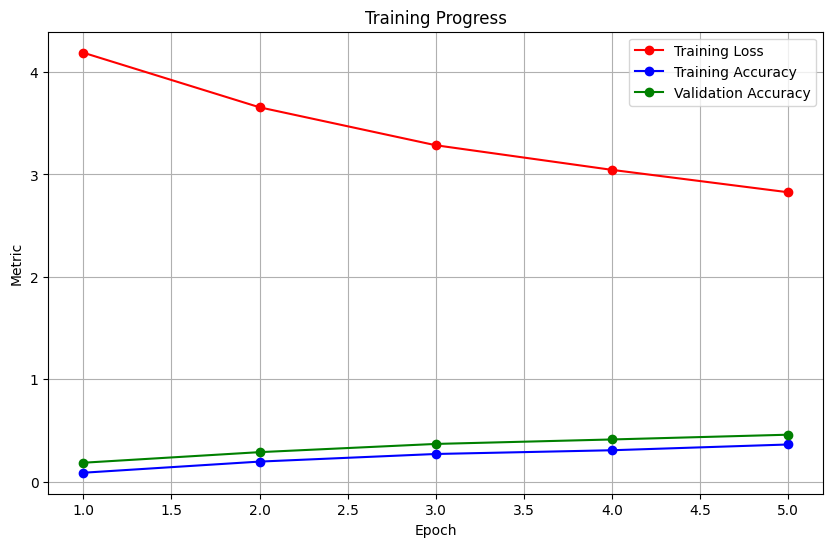

In [18]:
my_model = model_training(pretrained_model,0.001,5,train_loader=train_dataloader,val_dataloader=val_dataloader)